In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("akshaydattatraykhare/diabetes-dataset")

print("Path to dataset files:", path)

100%|██████████| 8.91k/8.91k [00:00<00:00, 6.73MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/akshaydattatraykhare/diabetes-dataset/versions/1


In [ ]:
df=pd.read_csv(path+"/diabetes.csv")

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.shape

(768, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


##Data cleaning

In [ ]:
df.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


##Task 5: Target Variable Analysis

In [ ]:
print(df["Outcome"].value_counts())
#0=No Diabetes
#1=Diabetes

Outcome
0    500
1    268
Name: count, dtype: int64


Text(0.5, 1.0, 'Target Variable Analysis')

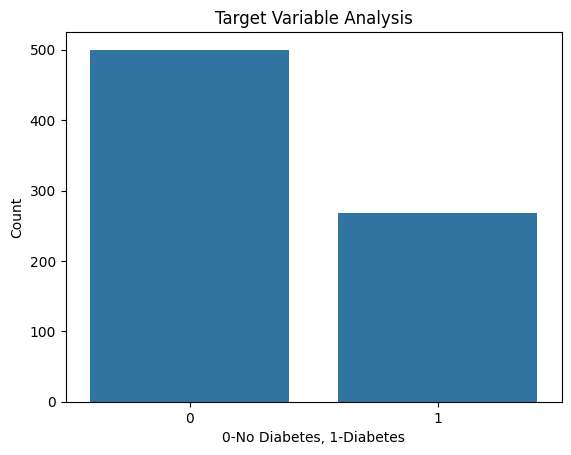

In [ ]:
sns.countplot(x="Outcome",data=df)
plt.xlabel("0-No Diabetes, 1-Diabetes")
plt.ylabel("Count")
plt.title("Target Variable Analysis")

##Task 6: Histograms

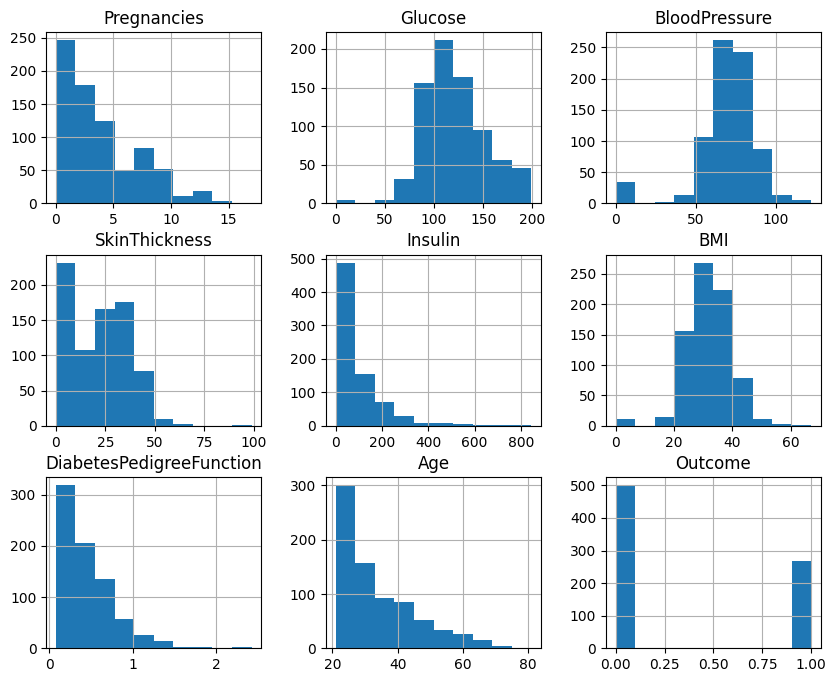

In [ ]:
df.hist(figsize=(10,8))
#X-axis = column values
#Y-axis = frequency/count
plt.show()

##Task 7: Correlation Heatmap

<Axes: >

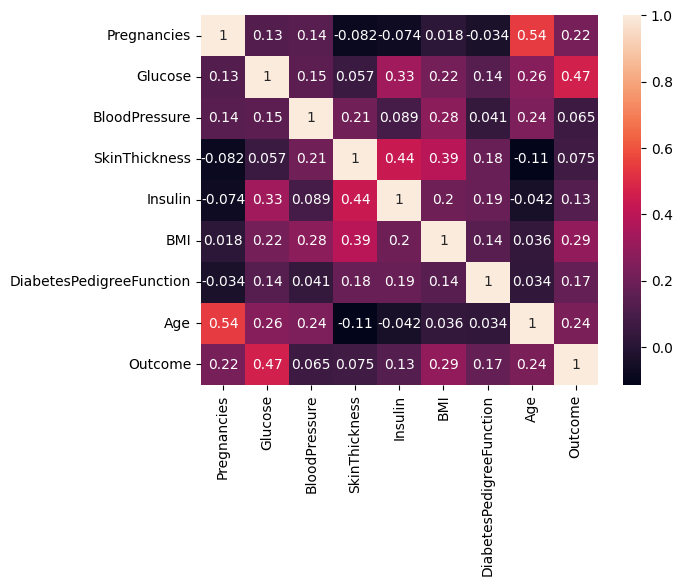

In [ ]:
sns.heatmap(df.corr(),annot=True)

<Axes: >

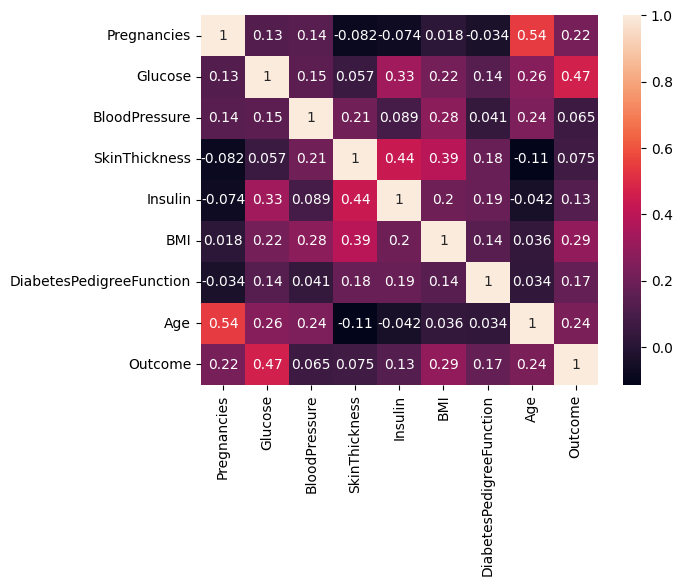

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
#Here outcome is the prediction

Both are same bcz there is no object

In [ ]:
corr=df.corr(numeric_only=True)["Outcome"]
print(corr.sort_values(ascending=False))

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


##Task 8: Split Features and Target

In [ ]:
X=df.drop("Outcome",axis=1)
#axis =1 means It Removes the Outcome column:
y=df["Outcome"]

##Task 9: Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=4)

##Task 10: Train Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
#max_iter=1000 allows the Logistic Regression model to make up to 1000 iterations to find the best solution and ensure convergence.
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

##Task 11: Prediction

In [ ]:
y_pred=model.predict(x_test)
print(y_pred[:10])
#the reason why we use [:10]is to print first 10 values

[0 0 0 0 0 1 1 0 1 0]


##Task 12:Accuracy

In [ ]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy  = {accuracy}")

Accuracy  = 0.8116883116883117


##Task 13: Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
k=pd.DataFrame(data=cm,columns=["Predicted No Diabetes","Predicted Diabetes"],index=["Actual No Diabetes","Actual Diabetes"])
k
# 78 = Model prediction correct(No Diabetes) True positive
# 21 = Model prediction wrong(Model prredicted = Yes , but actual =No) False Negative
# 18 = Model prediction wrong(Model predicted = No , But actual = Yes) False Positive
# 37 = Model prediction correct(Diabetes) True Negative

,Predicted No Diabetes,Predicted Diabetes
Actual No Diabetes,90,12
Actual Diabetes,17,35


<Axes: >

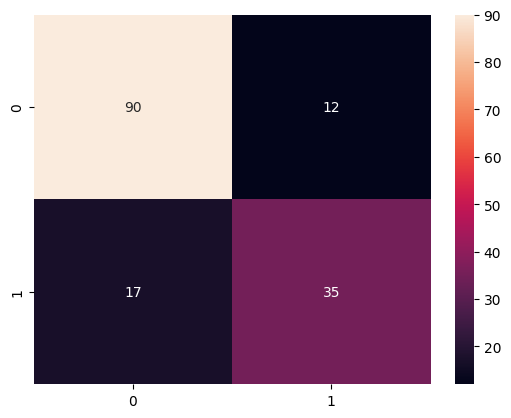

In [ ]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

In [ ]:
df.shape

(768, 9)

##Task 14: Classification Report

In [ ]:
from sklearn.metrics import classification_report
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       102
           1       0.74      0.67      0.71        52

    accuracy                           0.81       154
   macro avg       0.79      0.78      0.78       154
weighted avg       0.81      0.81      0.81       154

